In [1]:
import torch 
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
transform = transforms.Compose([transforms.ToTensor()])

In [3]:
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=False, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=False, transform=transform)

In [4]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [5]:
# defination of the model class
class FashionMNISTModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
            nn.LogSoftmax(dim=1)
        )
    
    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In [6]:
model = FashionMNISTModel()

In [7]:
# define loss function
loss_function = nn.NLLLoss()
optimizer = optim.Adam(model.parameters())

In [37]:
# Train model
def train(dataloader, model, loss_func, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # compute prediction and loss
        pred = model(X)
        loss = loss_func(pred, y)
        accuracy = get_accuracy(pred, y)
    
        # backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 100 == 0:
            current = batch * len(X)
            total_loss = loss.item()
            avg_loss = total_loss / (batch + 1)
            avg_accuracy = accuracy / (batch + 1) * 100
            print(f"Batch {batch}, Loss: {avg_loss:>7f},Accuracy: {avg_accuracy:>0.2f}%[{current:>5d}/{size:>5d}]")

            # loss, current = loss.item(), batch * len(X)
            # print(f"loss: {loss:>7f} [{current:>5d}/{size:>5d}]")


In [38]:
#  this was added later
def get_accuracy(pred, labels):
    _, predictions = torch.max(pred, 1)
    correct_guess = (predictions == labels).float().sum()
    accuracy = correct_guess / labels.shape[0]
    return accuracy

In [39]:
# Training process
epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1}\n--------------------------------")
    train(train_loader, model, loss_function, optimizer)
print("Done!")

Epoch 1
--------------------------------
Batch 0, Loss: 0.352799,Accuracy: 92.19%[    0/60000]


Batch 100, Loss: 0.002533,Accuracy: 0.91%[ 6400/60000]
Batch 200, Loss: 0.001211,Accuracy: 0.44%[12800/60000]
Batch 300, Loss: 0.000650,Accuracy: 0.31%[19200/60000]
Batch 400, Loss: 0.000799,Accuracy: 0.21%[25600/60000]
Batch 500, Loss: 0.000413,Accuracy: 0.18%[32000/60000]
Batch 600, Loss: 0.000455,Accuracy: 0.15%[38400/60000]
Batch 700, Loss: 0.000484,Accuracy: 0.12%[44800/60000]
Batch 800, Loss: 0.000343,Accuracy: 0.12%[51200/60000]
Batch 900, Loss: 0.000392,Accuracy: 0.10%[57600/60000]
Epoch 2
--------------------------------
Batch 0, Loss: 0.248590,Accuracy: 89.06%[    0/60000]
Batch 100, Loss: 0.002119,Accuracy: 0.91%[ 6400/60000]
Batch 200, Loss: 0.001502,Accuracy: 0.46%[12800/60000]
Batch 300, Loss: 0.001115,Accuracy: 0.30%[19200/60000]
Batch 400, Loss: 0.000933,Accuracy: 0.21%[25600/60000]
Batch 500, Loss: 0.000511,Accuracy: 0.18%[32000/60000]
Batch 600, Loss: 0.000363,Accuracy: 0.15%[38400/60000]
Batch 700, Loss: 0.000315,Accuracy: 0.13%[44800/60000]
Batch 800, Loss: 0.000374

In [40]:
def test(dataloader, model):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval() # set the model for evaluation
    test_loss, correct_guess = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_function(pred, y).item()
            correct_guess += (pred.argmax(1) ==y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct_guess /= size
    print(f"Test Error: \n Accuracy: {(100*correct_guess):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [41]:
# Evalaute model
test(test_loader, model)

Test Error: 
 Accuracy: 88.0%, Avg loss: 0.339972 



In [ ]:
def get_accuracy(pred, labels):
    _, predictions = torch.max(pred, 1)
    correct_guess = (predictions == labels).float().sum()
    accuracy = correct_guess / labels.shape[0]
    return accuracy

In [44]:
import matplotlib.pyplot as plt

In [45]:
def predict_single_image(image, label, model):
    model.eval() # set model for evaluation
    image = image.unsqueeze(0) # unsqueeze image as model expected batch dimension

    with torch.no_grad():
        prediction = model(image)
        print(prediction)
        predicted_label = prediction.argmax(1).item()

    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(f'Predicted: {predicted_label}, Actual: {label}')
    plt.show()

    return predicted_label

In [60]:
# choose image from test dataset
image, label = test_dataset[0] # hnge to another index for different image

tensor([[-12.1783, -20.7291, -13.6847, -15.8315, -15.8196,  -4.5635, -10.9217,
          -3.5158, -10.7786,  -0.0410]])


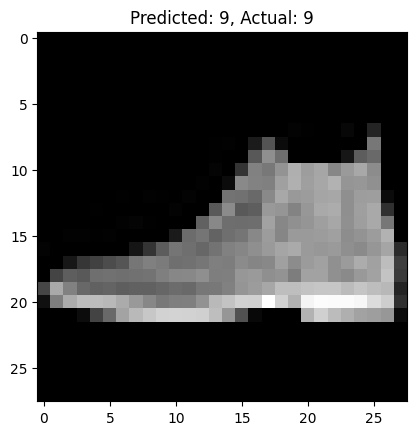

The model predicted 9, and the actual label is 9.


In [61]:
predicted_label = predict_single_image(image, label, model)
print(f"The model predicted {predicted_label}, and the actual label is {label}.")